In [1]:
import os
os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-23.jdk/Contents/Home"  # or wherever your JDK 17/21 lives
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [2]:
from pyspark.sql import SparkSession
spark = (
    SparkSession.builder.appName("Local Spark Session")
    .master("local[*]")
    .config("spark.sql.warehouse.dir", "spark-warehouse")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .enableHiveSupport()
    .getOrCreate()
)
print(spark.sparkContext.uiWebUrl)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/06 14:52:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


http://127.0.0.1:4040


How to read data in Spark. The basis is the DataFrameReader, we can access it by spark.read

## Read modes. 
Spark supports different read modes to handle corrupt or malformed data during the read process.
* Permissive: Default value. Sets all fields to null when encountering corrupt or malformed data.
* Drop Malformed: Drops the entire row containing corrupt or malformed data.
* Fail Fast: Throws an exception immediately upon encountering corrupt or malformed data.


## Save modes.
Spark supports also different saves modes when writing data to some location.
* Overwrite: Overwrites the existing data at the target location.
* Append: Appends the new data to the existing data at the target location.
* Ignore: Ignores the write operation if data already exists at the target location.
* ErrorIfExists: The default behavior. Throws an exception if data already exists at the target location.

## Query Pushdown
Query Pushdown means that Spark can try to do some operations directly on the source of the data without loading everything from the source.
Example:

```sql
dbDataFrame.select("DEST_COUNTRY_NAME").distinct().explain
== Physical Plan ==
*HashAggregate(keys=[DEST_COUNTRY_NAME#8108], functions=[])
+- Exchange hashpartitioning(DEST_COUNTRY_NAME#8108, 200)
+- *HashAggregate(keys=[DEST_COUNTRY_NAME#8108], functions=[])
+- *Scan JDBCRelation(flight_info) [numPartitions=1] ...
```

For example, when performing a filter we can see on the PushedFilters that these filteres where pushed to the source database.
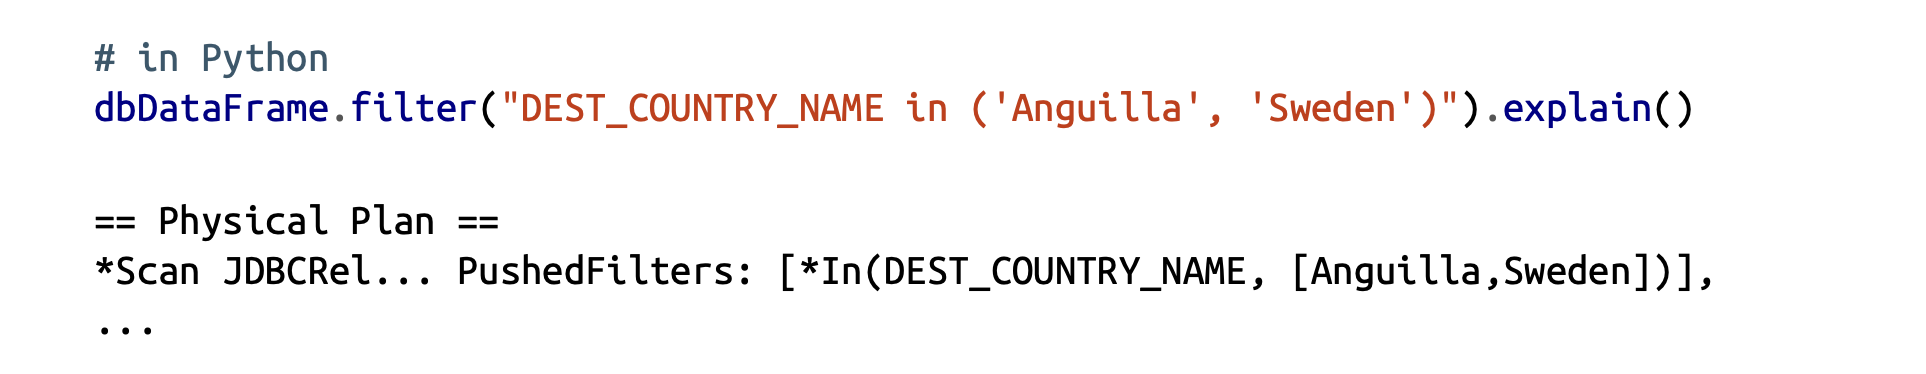


Spark can’t translate all of its own functions into the functions available in the SQL database in which you’re working. Therefore, sometimes you’re going to want to pass an entire query into your SQL that will return the results as a DataFrame. Now, this might seem like it’s a bit complicated, but it’s actually quite straightforward. Rather than specifying a table name, you just specify a SQL query. Of course, you do need to specify this in a special way; you must wrap the query in parenthesis and rename it to something—in this case, I just gave it the same table name:
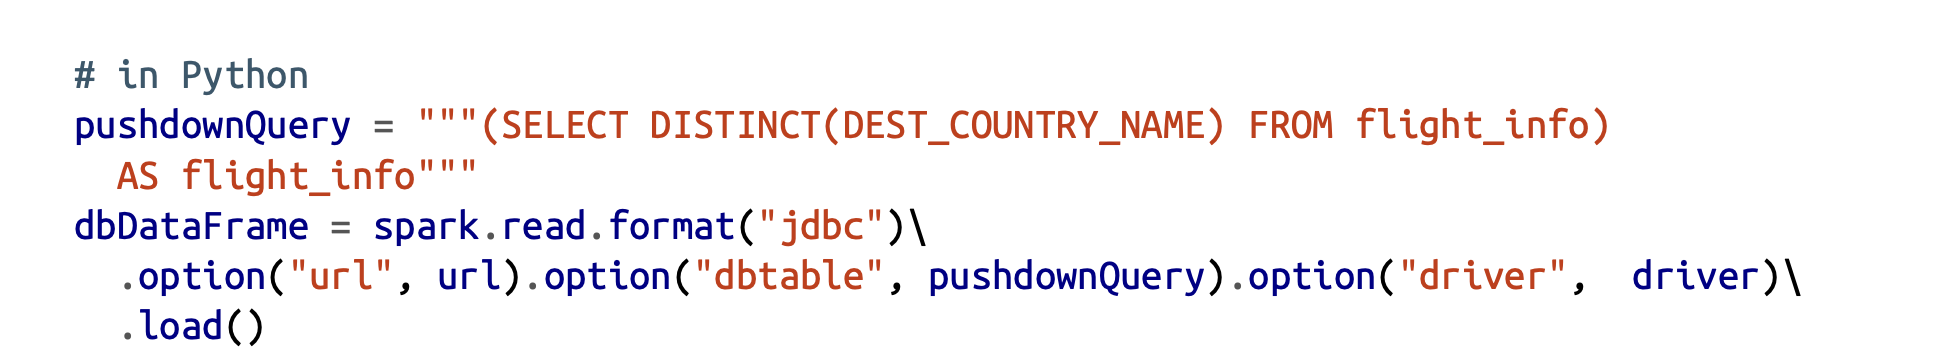

## Reading from databases in parallel
All throughout this book, we have talked about partitioning and its importance in data processing. Spark has an underlying algorithm that can read multiple files into one partition, or conversely, read multiple partitions out of one file, depending on the file size and the “splitability” of the file type and compression. The same flexibility that exists with files, also exists with SQL databases except that you must configure it a bit more manually. What you can configure, as seen in the previous options, is the ability to specify a maximum number of partitions to allow you to limit how much you are reading and writing in parallel.

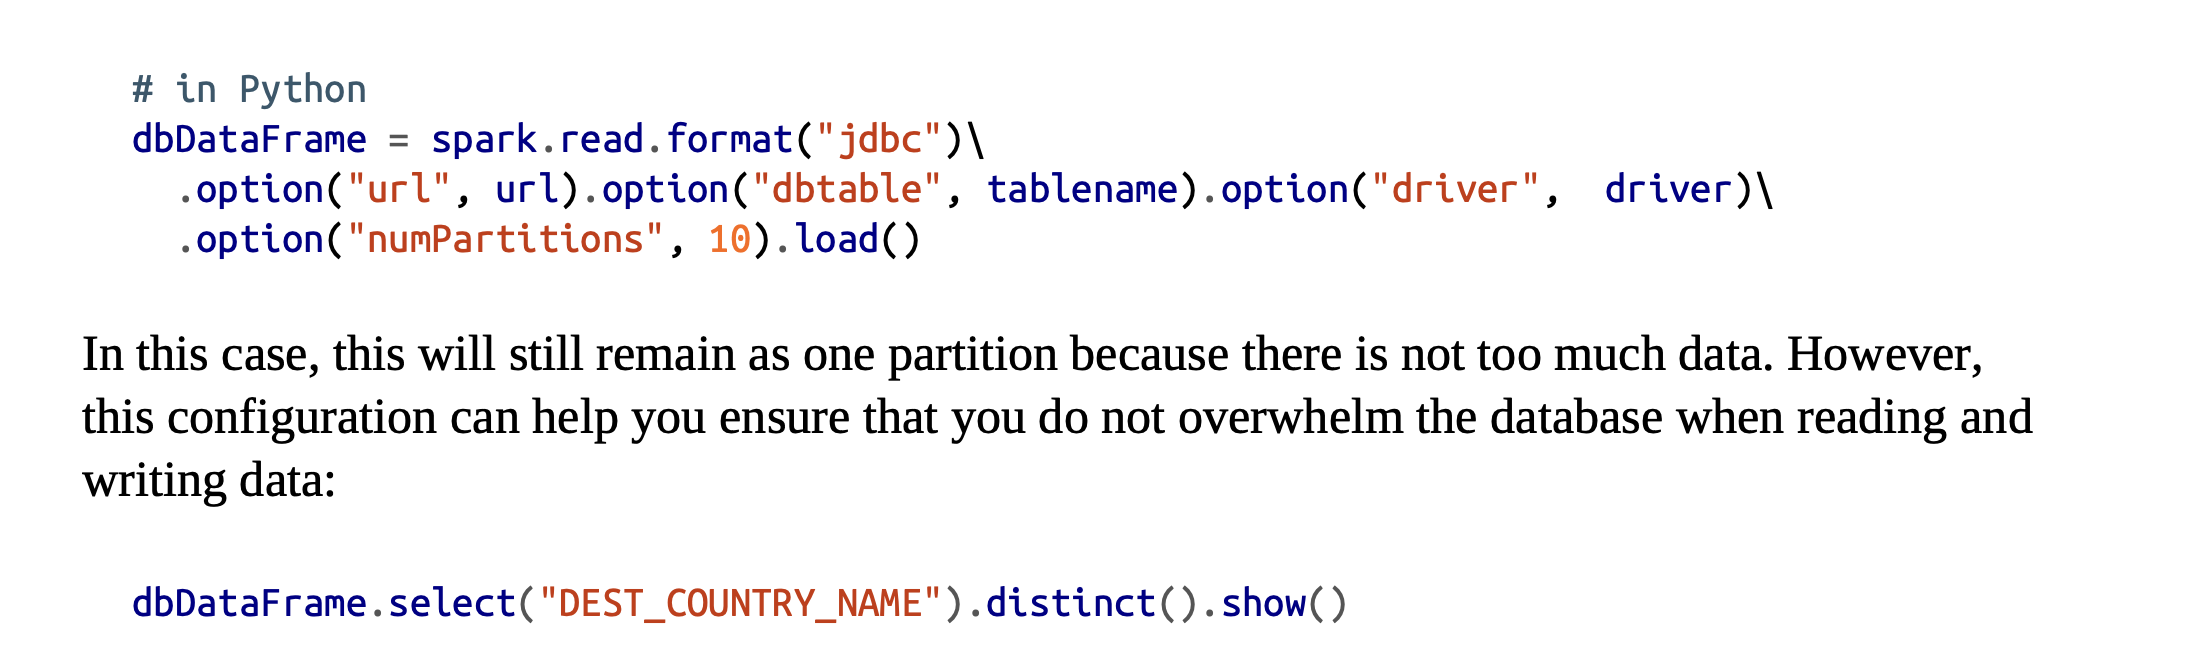

A **predicate** is a condition that evaluates to `true` or `false` per row. It appears in `filter()`/`where()`, join conditions, and `CASE WHEN`. Rows where it is `true` are kept; `false` and `null` are dropped (so `col != 'x'` also drops null rows).

```python
from pyspark.sql import functions as F

df.filter(F.col("amount") > 100)
df.where((F.col("country") == "PT") & F.col("active"))
df.join(other, df.id == other.id)
```

### Predicate pushdown
Catalyst pushes predicates as close to the data source as possible, so less data is read and shuffled:
- **Partition pruning:** skips partition folders that can't match.
- **File/row-group skipping:** uses Parquet min/max stats or Delta data skipping.
- **Source filtering:** JDBC sources run the filter in the database.

Check it with `df.explain(True)` and look for `PushedFilters` and `PartitionFilters`.

### What blocks pushdown
- Python UDFs in the predicate
- Wrapping the column in a function (`F.year("order_date") == 2026`) instead of a range on the raw column
- Casting the column instead of the literal

### Tips
- Filter as early as possible, using native column expressions.
- Keep transformations on the literal side, not the column side.
- On Delta, combine with partition columns and Z-order/liquid clustering.
- Always verify with `explain()`.

Here is one example on how to push predicates to the SQL database:
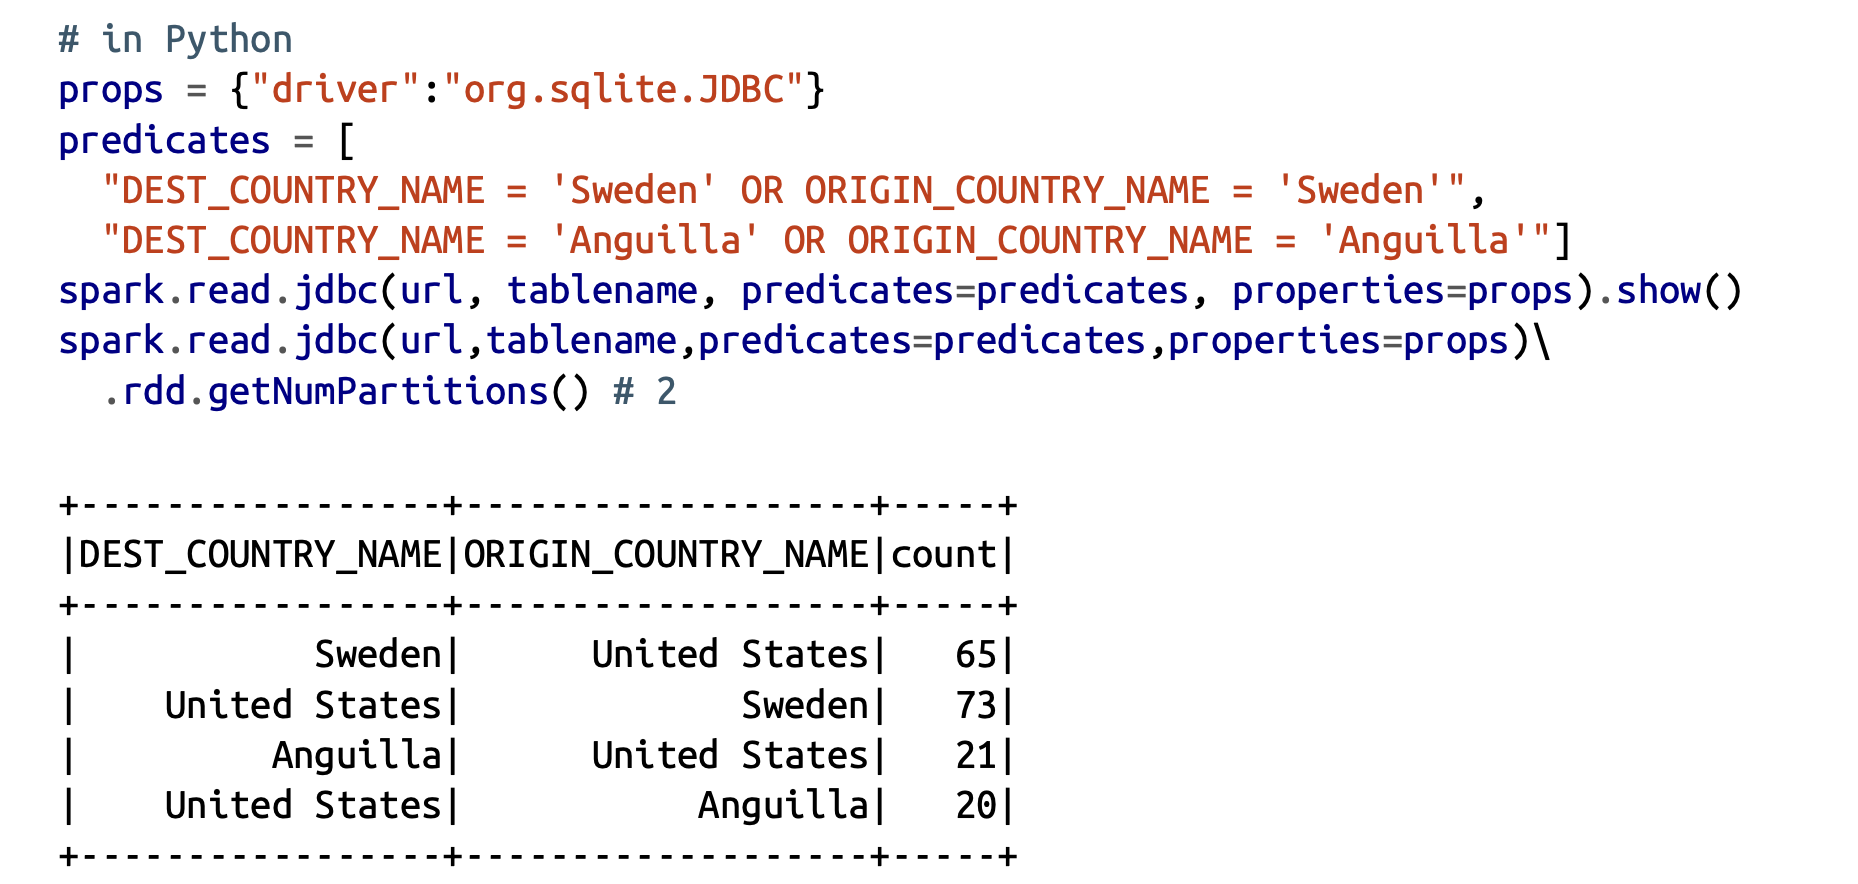


## Partitioning a JDBC read by column range
By default a JDBC read uses one partition and one connection. For a parallel read, pass a numeric column, bounds and a partition count:

```python
spark.read.jdbc(
    url, tablename,
    column="count",
    lowerBound=0,
    upperBound=348113,
    numPartitions=10,
    properties=props
)
```

- Spark splits the range into equal strides and runs one query per stride in parallel.
- **Bounds do not filter rows.** Values outside them go to the first or last partition.
- `numPartitions` = parallelism and max concurrent DB connections.
- The column must be numeric, date, or timestamp.
- Skewed data gives unbalanced partitions.
- Alternative: pass a list of explicit predicates, one per partition.

**NOTE: When writing to text files, we need to make sure to only have one column, otherwise it will fail.**

## Advanced I/O Concepts

**Write parallelism:** the number of output files equals the number of DataFrame partitions at write time. Control it with `repartition()` / `coalesce()`.

**Splittable files:** Spark can read parts of the same file in parallel instead of the whole file, and on HDFS it can align tasks with blocks.
- Splittable: Parquet, ORC, Avro, uncompressed CSV/JSON.
- A single gzip-compressed CSV/JSON is **not** splittable, so one task reads it all.

**Compression:** reduces storage and I/O, but splittability depends on codec and format.
- Raw text: only bzip2 is splittable (and slow).
- Parquet/ORC compress inside the file, so they stay splittable with any codec (snappy, gzip, zstd).
- Recommended: **Parquet** (the book suggests gzip; snappy or zstd are common modern choices).

### Data layout

**Partitioning (`partitionBy`)**
- One folder per value of the column, which enables partition pruning on reads.
- Use low-cardinality columns (date, country). High-cardinality columns (user_id) create too many small files.

```python
(df.write
   .format("parquet")
   .partitionBy("order_date")
   .mode("overwrite")
   .save("/data/sales"))

# Reading with a filter on the partition column only scans matching folders
spark.read.parquet("/data/sales").filter("order_date = '2026-10-01'")
```

**Bucketing (`bucketBy`)**
- Hashes a column into a **fixed number of buckets** (files), so rows with the same key always land in the same bucket.
- Pre-shuffles the data at write time, so later **joins, aggregations and window operations on that key avoid a shuffle**.
- Works with high-cardinality columns (customer_id), where `partitionBy` would not.
- Requires `saveAsTable` (the bucketing metadata lives in the metastore). `sortBy` is optional and sorts rows within each bucket.
- Both tables must be bucketed on the same column with the **same number of buckets** to benefit in a join.

```python
# Write two tables bucketed on the join key
(orders.write
   .format("parquet")
   .bucketBy(16, "customer_id")
   .sortBy("customer_id")
   .mode("overwrite")
   .saveAsTable("orders_bucketed"))

(customers.write
   .format("parquet")
   .bucketBy(16, "customer_id")
   .sortBy("customer_id")
   .mode("overwrite")
   .saveAsTable("customers_bucketed"))

# Shuffle-free join (no Exchange in the plan)
o = spark.table("orders_bucketed")
c = spark.table("customers_bucketed")
o.join(c, "customer_id").explain()

# Aggregation on the bucket key also avoids a shuffle
o.groupBy("customer_id").count().explain()
```

**Combining both**

```python
(df.write
   .format("parquet")
   .partitionBy("order_date")          # prune by date
   .bucketBy(8, "customer_id")         # co-locate by customer within each date
   .sortBy("customer_id")
   .saveAsTable("sales_part_bucketed"))
```

**Partitioning vs bucketing**

| | `partitionBy` | `bucketBy` |
|---|---|---|
| Layout | One folder per value | Fixed number of files |
| Best for | Filters (pruning) | Joins, aggregations |
| Column cardinality | Low | High |
| Needs `saveAsTable` | No | Yes |

**Notes**
- Bucketing helps most for tables that are joined repeatedly. For a one-off join, a normal shuffle is usually cheaper than writing bucketed data.
- On Delta/Databricks, bucketing is not supported for Delta tables. Use partitioning, Z-ordering or liquid clustering instead.